In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
import glob
import re

import datetime as dt
import pytz

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/bout")
sys.path.append("../src/tests")

In [3]:
import clustering as clstr
import bout.assembly as bt
import plot as bt_plt
import test_activity_metric_functions as test_actvt
import activity.subsampling as ss
import activity.activity_assembly as actvt
import pipeline
from core import SITE_NAMES, FREQUENCY_COLOR_MAPPINGS

from cli import get_file_paths
import pipeline

In [39]:
def plot_detections_regular(ax, audio_features, dets):
    start = audio_features['start']
    fs = audio_features['sample_rate']
    for i, row in dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor='yellow', facecolor='none', alpha=0.8)
        
        ax.add_patch(rect)

def calculate_activity_index_percentage_to_plot(dets, data_params, bout_params):
    blocks_per_cycle = actvt.get_activity_index_per_cycle(dets.copy(), data_params)
    inds_percent_per_cycle = actvt.get_activity_index_per_time_on_index(blocks_per_cycle, data_params)
    return np.round(inds_percent_per_cycle, 2)

def calculate_activity_index_raw_to_plot(dets, data_params, bout_params):
    blocks_per_cycle = actvt.get_activity_index_per_cycle(dets.copy(), data_params)
    return blocks_per_cycle

def calculate_num_calls_to_plot(dets, data_params, bout_params):
    num_dets_per_cycle = actvt.get_number_of_detections_per_cycle(dets.copy(), data_params['cycle_length'])
    return num_dets_per_cycle

def calculate_callrate_to_plot(dets, data_params, bout_params):
    num_dets_per_cycle = actvt.get_number_of_detections_per_cycle(dets.copy(), data_params['cycle_length'])
    callrate_per_cycle = actvt.get_metric_per_time_on(num_dets_per_cycle, data_params['time_on'])
    return callrate_per_cycle

def calculate_boutdur_to_plot(dets, data_params, bout_params):
    bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dets, data_params, bout_params)
    bout_duration_per_cycle = actvt.get_bout_duration_per_cycle(bout_metrics.copy(), data_params['cycle_length'])
    return np.round(bout_duration_per_cycle,2)

def calculate_btp_to_plot(dets, data_params, bout_params):
    bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dets, data_params, bout_params)
    bout_duration_per_cycle = actvt.get_bout_duration_per_cycle(bout_metrics.copy(), data_params['cycle_length'])
    btp_per_cycle = actvt.get_btp_per_time_on(bout_duration_per_cycle, data_params['time_on_in_secs'])
    return np.round(btp_per_cycle,2)

def get_windows_for_audio_seg_PST(audio_features):
    start = audio_features['start']
    duration = audio_features['duration']
    filename = audio_features['file_path'].name

    file_dt = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')
    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)   

    windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), 
                  file_dt_PST+pd.Timedelta(seconds=start+(duration%60))+pd.Timedelta(minutes=duration//60), 
                  freq=f'{duration//3}S', inclusive='both')
    
    return windows_PST
        
def plot_metrics_over_audio_seg(ax, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed detections
    """

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    duration = audio_features['duration']
    windows_PST = get_windows_for_audio_seg_PST(audio_features)
    legend_patches = [metric_to_plot['legend']]

    ax.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmax=0, vmin=spec_features['vmin'])
    if not(plot_dets.empty):
        ax.set_title(metric_to_plot['plot_title'], fontsize=plt.rcParams['font.size'])
        metric_to_plot['metric_per_cycle'] = metric_to_plot['calc_func'](plot_dets, data_params, bout_params)
        metric_to_plot['plot_func'](ax, audio_features, data_params, metric_to_plot)
    plot_detections_regular(ax, audio_features, plot_dets)
    if metric_to_plot['background_info']:
        metric_to_plot['background_func'](ax, audio_features, data_params, plot_dets, bout_params)
    ax.legend(handles=legend_patches, fontsize=plt.rcParams['font.size']-2, ncol=len(legend_patches), loc=1)
    ax.set_xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)))
    ax.set_xticklabels(labels=np.linspace(0, duration, len(windows_PST)).astype(int))

def plot_recording_periods_with_metric(ax, audio_features, data_params, metric_to_plot):
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']
    cycle_length = 60*data_params['cycle_length']
    time_on = data_params['time_on_in_secs']
    div_fac = 3
    if metric_to_plot['plot_title'] == f'Activity Index':
        div_fac = 4.8

    window_starts = np.arange(0, 1800, cycle_length)
    window_count = 0
    for window_start in window_starts:
        if (window_start < start+duration and window_start+time_on > start):
            if (window_start <= start):
                rect = patches.Rectangle((0, 0), (min(time_on, ((window_start+time_on)-start)))*fs/2, fs/2, 
                                        linewidth=4, edgecolor='yellow', facecolor='yellow', alpha=data_params['recording_alpha'])
                text_loc = (min(time_on, ((window_start+time_on)-start)))/div_fac
            elif (window_start+time_on) >= (start+duration):
                rect = patches.Rectangle(((window_start-start)*fs/2, 0), 
                                        (min(time_on, (start+duration) - window_start))*fs/2, fs/2, 
                                        linewidth=4, edgecolor='yellow', facecolor='yellow', alpha=data_params['recording_alpha'])
                text_loc =  (window_start-start) +(min(time_on, (start+duration) - window_start)/div_fac)
            else:
                rect = patches.Rectangle(((window_start-start)*fs/2, 0), 
                                            (time_on)*fs/2, fs/2, 
                                            linewidth=4, edgecolor='yellow', facecolor='yellow', alpha=data_params['recording_alpha'])
                text_loc =  (window_start-start) + (time_on/div_fac)
            if window_count<len(metric_to_plot['metric_per_cycle']):
                ax.text(x=text_loc*fs/2, y=0.60*(96/125), 
                         s=f"{metric_to_plot['metric_per_cycle'][window_count]}{metric_to_plot['unit']}", color='w', weight='bold')
            else:
                ax.text(x=text_loc*fs/2, y=0.60*(96/125), s=f"0{metric_to_plot['unit']}", color='w', weight='bold')
            window_count+=1
            ax.add_patch(rect)

def plot_activity_index_time_blocks(ax, audio_features, data_params, dets, bout_params):
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']
    index_time_block = data_params['index_time_block_in_secs']

    window_starts = np.arange(0, 1800, index_time_block)
    window_count = 0
    for window_start in window_starts:
        window_end = window_start+index_time_block
        if (window_start < start+duration and window_end > start):
            dets_in_block = dets[(dets['start_time']>=window_start)&(dets['end_time']<=window_end)].copy()
            dets_in_next_block = dets[(dets['start_time']>=window_end)&(dets['end_time']<=(window_end+index_time_block))].copy()
            if (window_start <= start):
                rectangle_startx = 0
                rectangle_starty = 0
                rectangle_width = (min(index_time_block, window_end-start))*fs/2
                rectangle_height = 1
            elif (window_end) >= (start+duration):
                rectangle_startx = (window_start-start)*fs/2
                rectangle_starty = 0
                rectangle_width = (min(index_time_block, (start+duration) - window_start))*fs/2
                rectangle_height = 1
            else:
                rectangle_startx = (window_start-start)*fs/2
                rectangle_starty = 0
                rectangle_width = (index_time_block)*fs/2
                rectangle_height = 1

            if len(dets_in_block)>0:
                ax.axhline(y=45/125, xmin=rectangle_startx/(duration*fs/2), xmax=(rectangle_startx/(duration*fs/2)) + (index_time_block/duration), linewidth=4, color='w')
                # if (dets_in_block.iloc[0]==dets.iloc[0]).all():
                #     ax.axvline(x=rectangle_startx, ymin=35/125, ymax=45/125, linewidth=4, color='w')
                # if (dets_in_block.iloc[-1]==dets.iloc[-1]).all():
                #     ax.axvline(x=rectangle_startx+rectangle_width, ymin=35/125, ymax=45/125, linewidth=4, color='w')
                if len(dets_in_next_block)==0:
                    ax.axvline(x=rectangle_startx+rectangle_width, ymin=35/125, ymax=45/125, linewidth=4, color='w')
            else:
                if len(dets_in_next_block)>0:
                    ax.axvline(x=rectangle_startx+rectangle_width, ymin=35/125, ymax=45/125, linewidth=4, color='w')

    
            rect1 = patches.Rectangle((rectangle_startx, rectangle_starty), rectangle_width, rectangle_height, 
                                        linewidth=2, edgecolor='w', facecolor='none', alpha=0.4)
            rect2 = patches.Rectangle((rectangle_startx, rectangle_starty), rectangle_width, rectangle_height, 
                                        linewidth=1, edgecolor='w', facecolor='none', alpha=1)
            window_count+=1
            # ax.add_patch(rect1)
            ax.add_patch(rect2)

def plot_bout_info(ax, audio_features, data_params, dets, bout_params):
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dets, data_params, bout_params)

    for i, row in bout_metrics.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['bout_duration_in_secs'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=4, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=0.8)
        ax.add_patch(rect)

In [5]:
site_key = 'Carp'
freq_key = 'LF'

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['SNR_threshold'] = 3
data_params['det_prob_threshold'] = 0.35
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0)
inds_where_dets_above_detection_probability = location_df['det_prob'].astype(float)>=data_params['det_prob_threshold']
location_df_above_detection_probability = location_df[inds_where_dets_above_detection_probability].copy()
inds_where_dets_above_SNR = location_df_above_detection_probability['SNR'].astype(float)>=data_params['SNR_threshold']
location_df_above_SNR_and_detthresh = location_df_above_detection_probability[inds_where_dets_above_SNR].copy()
bout_params = bt.get_bout_params_from_location(location_df_above_SNR_and_detthresh, data_params)

In [6]:
files_from_loc = sorted(list(Path(f'../data/audiomoth_recordings/').glob(pattern=f'*/{site_key}/*.WAV')))
files_from_loc

[PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220727_080000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_030000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_033000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_040000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_043000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_050000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_053000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_060000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_063000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_070000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_073000.WAV'),
 PosixPath('../data/audiomoth_recordings/recover-20220

In [7]:
file = files_from_loc[11]
file

PosixPath('../data/audiomoth_recordings/recover-20220728/Carp/20220728_080000.WAV')

In [8]:
file_path = Path(file)
filename = file_path.name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate
start = 60
duration = 60
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))
vmin = -60 # hide anything below -rm_dB dB

data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['cur_dc_tag'] = '1of1'
data_params['cycle_length'] = int(data_params['cur_dc_tag'].split('of')[-1])
data_params['time_on'] = int(data_params['cur_dc_tag'].split('of')[0])
data_params['time_on_in_secs'] = 60*data_params['time_on']
data_params['index_time_block_in_secs'] = 5
data_params['recording_alpha'] = 0.0
dc_applied_df = ss.simulate_dutycycle_on_detections(location_df_above_SNR_and_detthresh.copy(), data_params)

file_dt_start = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
file_dt_end = file_dt_start + pd.Timedelta(minutes=30)

start_time_bounds = pd.to_datetime(dc_applied_df['call_start_time'])>=file_dt_start
end_time_bounds = pd.to_datetime(dc_applied_df['call_end_time'])<=file_dt_end
plot_dets = dc_applied_df.loc[start_time_bounds&end_time_bounds]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]

In [9]:
audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (14, 5.5)

spec_features = dict()
spec_features['vmin'] = vmin
spec_features['NFFT'] = 1024
spec_features['cmap'] = 'jet'

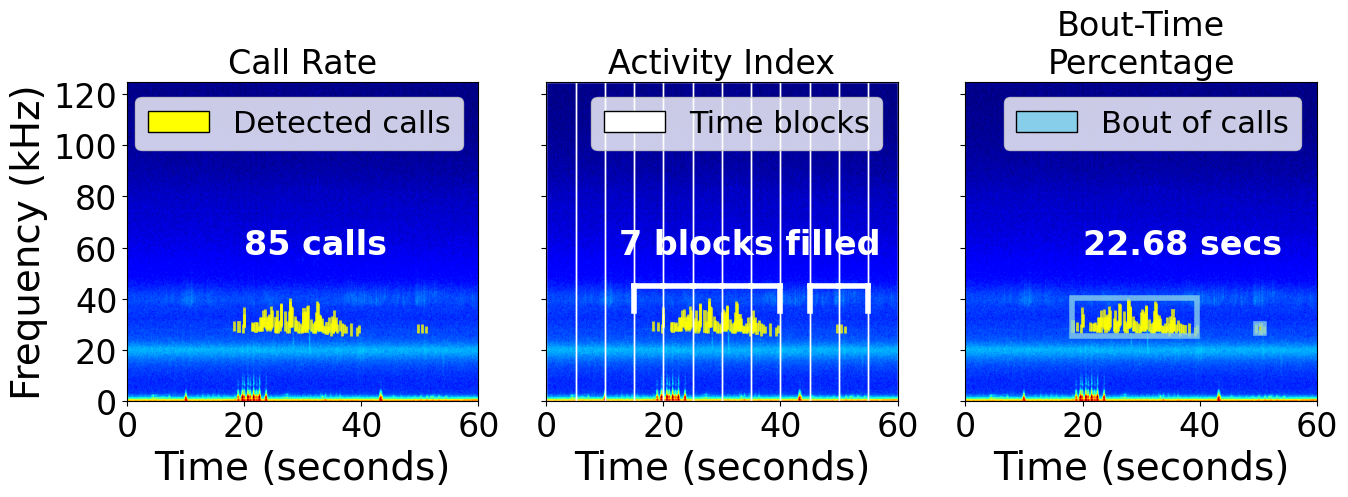

In [40]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=audio_features['figsize'], constrained_layout=True, sharey=True)
plt.rcParams.update({'font.size': 24})
y_top = fs/2

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Call Rate'
metric_to_plot['unit'] = ' calls'
metric_to_plot['legend'] = patches.Patch(facecolor='yellow', edgecolor='k', label='Detected calls')
metric_to_plot['calc_func'] = calculate_num_calls_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = False
plot_metrics_over_audio_seg(ax1, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
y_labs = np.arange(0, y_top, 20000)
ax1.set_yticks(ticks=y_labs/y_top)
ax1.set_yticklabels(labels=(y_labs/1000).astype('int'))
ax1.set_ylim(0, 1)
ax1.set_ylabel("Frequency (kHz)", fontsize=plt.rcParams['font.size']+4)
ax1.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Activity Index'
metric_to_plot['unit'] = ' blocks filled'
metric_to_plot['legend'] = patches.Patch(facecolor='w', edgecolor='k', label='Time blocks')
metric_to_plot['calc_func'] = calculate_activity_index_raw_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = True
metric_to_plot['background_func'] = plot_activity_index_time_blocks
plot_metrics_over_audio_seg(ax2, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
ax2.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)
ax2.set_ylim(0, 1)

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Bout-Time\nPercentage'
metric_to_plot['unit'] = ' secs'
metric_to_plot['legend'] = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS[data_params['type_tag']], edgecolor='k', label='Bout of calls')
metric_to_plot['calc_func'] = calculate_boutdur_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = True
metric_to_plot['background_func'] = plot_bout_info

plot_metrics_over_audio_seg(ax3, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
ax3.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)
ax3.set_ylim(0, 1)
fig.tight_layout()

fig.savefig('20250206__FIG3ABC_adityas_manuscript.png', bbox_inches='tight')
plt.show()

In [22]:
22.68/60

0.378

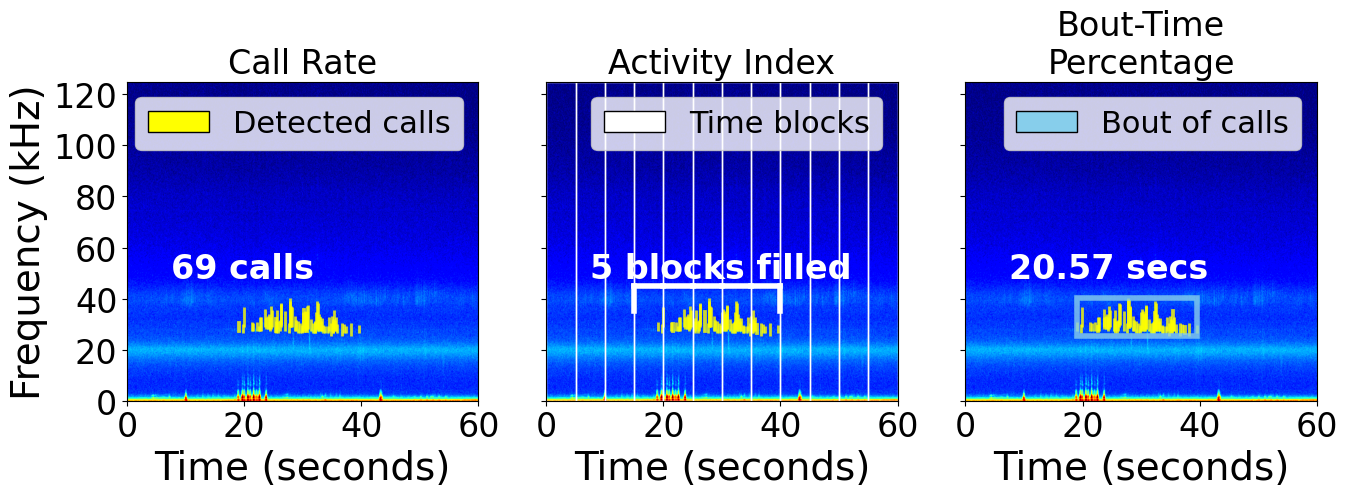

In [31]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=audio_features['figsize'], constrained_layout=True, sharey=True)
plt.rcParams.update({'font.size': 24})
y_top = fs/2

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Call Rate'
metric_to_plot['unit'] = ' calls'
metric_to_plot['legend'] = patches.Patch(facecolor='yellow', edgecolor='k', label='Detected calls')
metric_to_plot['calc_func'] = calculate_num_calls_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = False
plot_metrics_over_audio_seg(ax1, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
y_labs = np.arange(0, y_top, 20000)
ax1.set_yticks(ticks=y_labs/y_top)
ax1.set_yticklabels(labels=(y_labs/1000).astype('int'))
ax1.set_ylim(0, 1)
ax1.set_ylabel("Frequency (kHz)", fontsize=plt.rcParams['font.size']+4)
ax1.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Activity Index'
metric_to_plot['unit'] = ' blocks filled'
metric_to_plot['legend'] = patches.Patch(facecolor='w', edgecolor='k', label='Time blocks')
metric_to_plot['calc_func'] = calculate_activity_index_raw_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = True
metric_to_plot['background_func'] = plot_activity_index_time_blocks
plot_metrics_over_audio_seg(ax2, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
ax2.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)
ax2.set_ylim(0, 1)

metric_to_plot = dict()
metric_to_plot['plot_title'] = f'Bout-Time\nPercentage'
metric_to_plot['unit'] = ' secs'
metric_to_plot['legend'] = patches.Patch(facecolor=FREQUENCY_COLOR_MAPPINGS[data_params['type_tag']], edgecolor='k', label='Bout of calls')
metric_to_plot['calc_func'] = calculate_boutdur_to_plot
metric_to_plot['plot_func'] = plot_recording_periods_with_metric
metric_to_plot['background_info'] = True
metric_to_plot['background_func'] = plot_bout_info

plot_metrics_over_audio_seg(ax3, audio_features, spec_features, plot_dets, data_params, bout_params, metric_to_plot)
ax3.set_xlabel("Time (seconds)", fontsize=plt.rcParams['font.size']+4)
ax3.set_ylim(0, 1)
fig.tight_layout()

fig.savefig('FIG3ABC_adityas_manuscript.png', bbox_inches='tight')
plt.show()